# Matemática IV

# Trabajo Práctico Final: Ciencia de Datos

## Análisis de Datos del Transporte Aéreo en Argentina

**Integrantes:**  
- Baselli María  
- Fernández Emiliano  
- Letelle Mauro

# Índice

1. Introducción
2. Fuente de datos
3. Contexto del proyecto
5. Carga de datos
6. Preguntas
7. Conclusiones
8. Bibliografía

# Introducción

Desde hace unos años, el sector aerocomercial de la República Argentina muestra un crecimiento sostenido en cuanto al movimiento de pasajeros, cantidad de vuelos, presencia de compañías aéreas y rutas disponibles.  Tal es así, que 2025 fue un año récord tanto en cabotaje como en vuelos internacionales: más de cincuenta millones de pasajeros transportados (ANAC).

Dada la relevancia de este medio de transporte, no solo como generador de actividad económica y empleo, sino también como factor clave para reducir distancias, mejorar la conectividad e impulsar el desarrollo federal, se lo eligió como objeto de análisis para aplicar los conocimientos adquiridos en la materia.

Simulando la solicitud de un organismo de planificación turística de Bariloche, el análisis pretende identificar patrones de demanda y distribución de los servicios aéreos, como también aspectos relacionados con la puntualidad y regularidad de los servicios.

Para ello recopilamos información de tres datasets: dos pertenecientes a la Administración Nacional de la Aviación Civil de la República Argentina (ANAC) y uno de Failbondi, una plataforma dedicada a visibilizar el funcionamiento operativo de las compañías aéreas que operan en el pais.

Los datos de origen gubernamental abarcan el período comprendido entre el 1 de enero de 2019 y el 30 de abril de 2026, mientras que el dataset proveniente de la página web mencionada cubre el intervalo entre el 1 de enero de 2024 y el 1 de agosto de 2026.

El presente trabajo comprende las etapas de carga, inspección, limpieza, preparación, exploración y visualización de los datos, cómo así también el análisis exploratorio y la aplicación de herramientas estadísticas y probabilísticas, con el objetivo de obtener una mejor comprensión del comportamiento del mercado aerocomercial argentino en Bariloche.


Todo el análisis se ejecuta localmente desde este repositorio y los archivos crudos se encuentran en `datasets/`.

# Fuente de datos

El notebook utiliza tres conjuntos de datos locales:

1. **Conectividad aérea**  
   Archivos: `conectividad_aerea_cabotaje.csv`, `conectividad_aerea_internacional.csv`,
   Contienen vuelos, pasajeros, asientos, aerolíneas, rutas, origen, destino, clase de vuelo y fecha. En los archivos disponibles cubren el período **2019-2026**.

2. **Aterrizajes y despegues ANAC**  
   Archivos: `202512-informe-ministerio-actualizado-dic-final.csv`,
    `202412-informe-ministerio-actualizado-dic-final.csv`,
    `202312-informe-ministerio-actualizado-dic.csv`,    
    `202604-informe-ministerio.csv`, 
   Contienen movimientos aeroportuarios, `Pasajeros`, `PAX`, fecha, hora, aeropuerto, aerolínea, tipo de movimiento y clasificación del vuelo. En ANAC, `Pasajeros` y `PAX` no son equivalentes: `Pasajeros` mide personas por movimiento aeroportuario y `PAX` se usa como pasajeros equivalentes para demanda agregada. Con los CSV locales actuales cubren **2023-2026**. 

3. **Failbondi**  
   Archivo: `failbondi-2026-05-20-dump.json`.  
   Contiene vuelos, aerolínea, aeropuerto, movimiento, estado, matrícula, aeronave, fecha programada y diferencia temporal respecto de la operación prevista. Como el dump fue generado el **20/05/2026**, se recortan vuelos posteriores a esa fecha para no analizar vuelos futuros como si fueran observados.

Fuentes mencionadas:

- Tableros Yvera: https://tableros.yvera.tur.ar/conectividad/
- Datos abiertos ANAC: https://www.datos.gob.ar/
- Failbondi: https://failbondi.fail/acerca

# Contexto del Proyecto

El organismo de planificación turística de San Carlos de Bariloche ha solicitado un informe técnico basado en datos reales de operaciones aeroportuarias. Debido al crecimiento sostenido del turismo, la infraestructura de la ciudad y el aeropuerto se ven exigidos, especialmente en las temporadas de invierno y verano.
Objetivo: El  organismo necesita entender la dinámica de los arribos y partidas para:

    - Optimizar el transporte público y traslados: Ajustar las frecuencias de colectivos y servicios de traslados según el volumen de pasajeros por hora.
    - Prever la saturación de la terminal: Identificar momentos críticos donde la cantidad de vuelos supere la capacidad operativa.
    - Planificación estratégica: Utilizar modelos estadísticos para predecir flujos futuros basados en tendencias históricas.

# Carga de librerías y archivos

In [173]:
# Librerías estándar de Python
from pathlib import Path        # Manejo de rutas de archivos multiplataforma
from math import comb, exp, factorial  # Funciones matemáticas para modelos probabilísticos
import json                     # Lectura de archivos JSON (dataset failbondi)
from scipy.stats import poisson   #Calcular poisson


# Librerías de análisis de datos y visualización
import numpy as np              # Operaciones numéricas y arrays
import pandas as pd             # Manipulación de DataFrames
import matplotlib.pyplot as plt # Generación de gráficos

# Compatibilidad con entornos sin IPython (e.g. scripts locales)
try:
    from IPython.display import display
except ImportError:
    display = print


In [174]:
# Nombres de los archivos requeridos para el análisis
ARCHIVOS_REQUERIDOS = [
    'conectividad_aerea_cabotaje.csv',
    'conectividad_aerea_internacional.csv',
    '202512-informe-ministerio-actualizado-dic-final.csv',
    '202412-informe-ministerio-actualizado-dic-final.csv',
    '202312-informe-ministerio-actualizado-dic.csv',    
    '202604-informe-ministerio.csv',
    'failbondi-2026-05-20-dump.json',
]

def resolver_data_dir():
    """
    Busca automáticamente la carpeta que contiene todos los datasets requeridos.
    Prueba distintas rutas candidatas para funcionar tanto en entornos locales
    como en Google Colab o Drive.
    Retorna el Path a la carpeta encontrada, o lanza FileNotFoundError si no la encuentra.
    """
    candidatos = [
        Path.cwd() / 'datasets',
        Path.cwd(),
        Path.cwd().parent / 'datasets',
        Path.cwd() / '4' / 'datasets',
        Path('/content') / 'datasets',
        Path('/content'),
        Path('/content/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica IV/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica_IV/4') / 'datasets',
    ]

    for data_dir in candidatos:
        if data_dir.exists() and all((data_dir / archivo).exists() for archivo in ARCHIVOS_REQUERIDOS):
            return data_dir

    raise FileNotFoundError(
        'No se encontraron todos los datasets. '
        'Asegurate de que estén en una carpeta "datasets/" dentro del proyecto.'
    )

# Ruta a la carpeta de datasets (se detecta automáticamente)
DATA_DIR = resolver_data_dir()

# Ruta raíz del proyecto (un nivel arriba de datasets/)
BASE_DIR = DATA_DIR.parent if DATA_DIR.name == 'datasets' else DATA_DIR

# Listado de archivos presentes en la carpeta de datasets
archivos = sorted(p.name for p in DATA_DIR.iterdir())
print('Carpeta de datasets:', DATA_DIR)
print('Datasets encontrados:')
for nombre in archivos:
    print('-', nombre)


Carpeta de datasets: c:\Users\emife\MateIV_Transporte_Publico\datasets
Datasets encontrados:
- 202312-informe-ministerio-actualizado-dic.csv
- 202412-informe-ministerio-actualizado-dic-final.csv
- 202512-informe-ministerio-actualizado-dic-final.csv
- 202604-informe-ministerio.csv
- conectividad_aerea_cabotaje.csv
- conectividad_aerea_internacional.csv
- failbondi-2026-05-20-dump.json


# Carga e inspección de datasets

In [175]:
# Diccionario para traducir nombres de días del inglés al español
DIAS = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

def leer_anac(nombre_archivo):
    """
    Carga un archivo CSV de movimientos aeroportuarios de ANAC y lo preprocesa.
    - Usa on_bad_lines='warn' para registrar (sin detener) las filas con errores de formato.
    - Convierte las columnas 'Pasajeros' y 'PAX' a numérico (invalidos → NaN).
    - Parsea 'Fecha UTC' como datetime con formato día/mes/año.
    - Agrega columnas derivadas: año, mes y día de la semana en español.
    """
    df = pd.read_csv(DATA_DIR / nombre_archivo, sep=';', decimal=',', on_bad_lines='warn')
    # Eliminar espacios en los nombres de columnas
    df.columns = df.columns.str.strip()

    # Convertir columnas de pasajeros a numérico (errores se convierten en NaN)
    for columna in ['Pasajeros', 'PAX']:
        df[columna] = pd.to_numeric(df[columna], errors='coerce')

    # Parsear fecha con formato día primero
    df['Fecha UTC'] = pd.to_datetime(
        df['Fecha UTC'],
        dayfirst=True,
        errors='coerce'
    )

    # Columnas temporales derivadas para facilitar los agrupamientos
    df['anio'] = df['Fecha UTC'].dt.year
    df['mes'] = df['Fecha UTC'].dt.month
    df['dia_semana'] = df['Fecha UTC'].dt.day_name().map(DIAS)

    return df

# Cargar los dos archivos ANAC disponibles
anac_2023 = leer_anac ('202312-informe-ministerio-actualizado-dic.csv')
anac_2024 = leer_anac('202412-informe-ministerio-actualizado-dic-final.csv')
anac_2025 = leer_anac('202512-informe-ministerio-actualizado-dic-final.csv')
anac_2026 = leer_anac('202604-informe-ministerio.csv')

# Unificar ambos períodos en un único DataFrame
anac = pd.concat([anac_2023, anac_2024, anac_2025, anac_2026], ignore_index=True)

# Filtrar únicamente los vuelos del aeropuerto de Bariloche (código IATA: BAR)
bariloche = anac[anac['Aeropuerto'] == 'BAR'].copy()


In [ ]:
# Resumen general del dataset unificado ANAC 

print("CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC")
print()
#Cantidad de filas del dataset
print('Filas cabotaje:', len(anac[anac['Clasificación Vuelo'] == 'Doméstico']))
print('Filas internacional:', len(anac[anac['Clasificación Vuelo'] == 'Internacional']))
print('Filas totales:', len(anac))

# Rango temporal cubierto por el dataset
fecha_inicio = anac['Fecha UTC'].min()
fecha_fin    = anac['Fecha UTC'].max()

print()
print("RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC")
print()
print("Fecha de inicio del dataset:", fecha_inicio.strftime('%d/%m/%Y'))
print("Fecha fin del dataset:",       fecha_fin.strftime('%d/%m/%Y'))

print()
print("INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC")
print()
# Tipos de datos, cantidad de nulos y uso de memoria por columna
anac.info()


----------------------------------------------------------------------------------------------------
CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

Filas cabotaje: 1540319
Filas internacional: 390539
Filas totales: 1930858

----------------------------------------------------------------------------------------------------
RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

Fecha de inicio del dataset: 01/01/2023
Fecha fin del dataset: 30/04/2026

----------------------------------------------------------------------------------------------------
INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

<class 'pandas.DataFrame'>
RangeIndex: 1930858 entries, 0 to 1930857
Data columns (total 1

In [177]:
# Visualización de las primeras filas para verificar la carga correcta del dataset
display(anac.head())


,Fecha UTC,Hora UTC,Clase de Vuelo (todos los vuelos),Clasificación Vuelo,Tipo de Movimiento,Aeropuerto,Origen / Destino,Aerolinea Nombre,Aeronave,Pasajeros,PAX,Calidad dato,anio,mes,dia_semana
0,2023-01-01,0:01,Regular,Internacional,Aterrizaje,EZE,LEMD,IBERIA - LINEAS AÉREAS DE ESPAÑA,0,199.0,199.0,DEFINITIVO,2023,1,Domingo
1,2023-01-01,0:10,Regular,Doméstico,Despegue,IGU,EZE,JETSMART AIRLINES S.A.,AIB-A320-232,67.0,33.5,DEFINITIVO,2023,1,Domingo
2,2023-01-01,0:15,Regular,Internacional,Aterrizaje,AER,SBPA,AEROLINEAS ARGENTINAS SA,BO-B-737-76N,36.0,36.0,DEFINITIVO,2023,1,Domingo
3,2023-01-01,0:17,Regular,Doméstico,Aterrizaje,SAL,AER,JETSMART AIRLINES S.A.,AIB-A320-232,168.0,84.0,DEFINITIVO,2023,1,Domingo
4,2023-01-01,0:19,Regular,Doméstico,Aterrizaje,AER,OSA,AEROLINEAS ARGENTINAS SA,EMB-ERJ190100IGW,17.0,8.5,DEFINITIVO,2023,1,Domingo


Exploramos la cantidad de pasajeros que aterrizaron en los diferentes aeropuertos durante el periodo del dataset

In [178]:
# Total de pasajeros (PAX) que aterrizaron en cada aeropuerto durante el período del dataset.
# Se filtra solo por 'Aterrizaje' para no duplicar conteos con las salidas.
pax_por_aeropuerto = (
    anac[anac['Tipo de Movimiento'] == 'Aterrizaje']
        .groupby('Aeropuerto', as_index=False)['PAX']
        .sum()
        .sort_values('PAX', ascending=False)
)

print(pax_por_aeropuerto)


   Aeropuerto         PAX
0         AER  17166943.0
18        EZE  16119650.5
5         CBA   3238111.5
13        DOZ   2539284.0
2         BAR   2132946.0
25        IGU   1387828.5
42        SAL   1316572.5
33        NEU   1013301.0
53        USU    997192.5
16        ECA    775607.0
51        TUC    728409.5
39        ROS    572115.5
8         CRV    464079.5
27        JUJ    438404.5
37        POS    297106.0
6         CHP    260070.5
30        MDP    252232.5
49        TRE    238556.0
3         BCA    199202.0
7         CRR    194119.5
43        SDE    188601.0
44        SIS    175830.5
26        JUA    172480.5
21        GAL    149159.5
14        DRY    146745.0
24        GRA    110889.5
20        FSA     80962.5
17        ESQ     76905.0
4         CAT     75426.5
47        SVO     74426.0
28        LAR     62483.0
52        UIS     53637.0
45        SRA     39647.5
34        OSA     37966.0
36        PAR     37223.0
19        FDO     34194.0
54        VIE     29712.0
48        TR

# Limpieza y preparación de datos


In [179]:
# El archivo 2025 contiene filas con errores de formato que Pandas no puede leer.
# Este bloque cuantifica cuántas filas fueron descartadas durante la carga.

archivo = DATA_DIR / '202512-informe-ministerio-actualizado-dic-final.csv'

# Contar el total de líneas en el archivo (incluyendo encabezado y filas corruptas)
with open(archivo, encoding='utf-8') as f:
    total_lineas = sum(1 for _ in f)

# Cargar solo las filas válidas (on_bad_lines='skip' descarta las corruptas silenciosamente)
df_check = pd.read_csv(
    archivo,
    sep=';',
    decimal=',',
    engine='python',
    on_bad_lines='skip'
)

filas_validas   = len(df_check)
filas_ignoradas = total_lineas - filas_validas  # diferencia = filas corruptas + encabezado

print("Total de líneas:", total_lineas)
print("Filas cargadas:", filas_validas)
print("Filas ignoradas:", filas_ignoradas)


Total de líneas: 597785
Filas cargadas: 597784
Filas ignoradas: 1


In [180]:
# Tabla resumen con dimensiones del dataset unificado
resumen_datasets = pd.DataFrame({
    'dataset':  ['ANAC'],
    'filas':    [len(anac)],
    'columnas': [anac.shape[1]],
})
display(resumen_datasets)

# Conteo de valores nulos en las columnas más relevantes para el análisis
print('Nulos principales en ANAC:')
display(anac[['Fecha UTC', 'Clasificación Vuelo', 'Tipo de Movimiento', 'Pasajeros', 'PAX']].isna().sum())


,dataset,filas,columnas
0,ANAC,1930858,15


Nulos principales en ANAC:


Fecha UTC              0
Clasificación Vuelo    0
Tipo de Movimiento     0
Pasajeros              0
PAX                    0
dtype: int64

# Análisis estadístico descriptivo para Bariloche


Medidas de Tendencia Central: Media y mediana de pasajeros diarios en el aeropuerto de Bariloche.

# ¿Por qué usamos la columna PASAJEROS?


La columna pasajeros refiere a la cantidad de pasajeros por operación individual (despegue/aterrizaje). Para vuelos de cabotaje se registra despegue y aterrizaje. Por ejemplo: en una vuelo Buenos Aires - Bariloche se cuenta al pasajero en el despegue y en el aterrizaje.
Al analizar un Aeropuerto individual se debe tomar el dato de esta columna. Por esta razón para analizar Bariloche vamos a usar la columna Pasajeros.

PAX: 1pax = 1tarjeta de embarque. Usar esta columna al analizar la cantidad de pasajeros cabotaje a nivel total país. Al analizar los pasajeros internacionales es indiferente usar esta columna o la anterior 

# ¿Cuál es la media y la mediana de pasajeros?

In [181]:
# Agrupar por fecha para obtener el total de pasajeros (PAX) por día en Bariloche
pasajeros_diarios = bariloche.groupby('Fecha UTC')['Pasajeros'].sum()

# Medidas de tendencia central
media_pasajeros   = pasajeros_diarios.mean()   # Promedio aritmético
mediana_pasajeros = pasajeros_diarios.median() # Valor central de la distribución

In [182]:
print(
    f"Media: Es el promedio aritmético de pasajeros por día. "
    f"Si la afluencia fuera constante durante todo el año "
    f"el destino debería esperar un movimiento de cercano a "        
    f"{media_pasajeros:.0f} pasajeros por día en el aeropuerto."   
)

Media: Es el promedio aritmético de pasajeros por día. Si la afluencia fuera constante durante todo el año el destino debería esperar un movimiento de cercano a 6806 pasajeros por día en el aeropuerto.


In [183]:
print(
     f"La mediana es el valor que divide los datos a la mitad. Indica que el 50% de los días llegan "
     f"menos de {mediana_pasajeros:.0f} pasajeros y el otro 50% llegan más."
)

La mediana es el valor que divide los datos a la mitad. Indica que el 50% de los días llegan menos de 6658 pasajeros y el otro 50% llegan más.


# ¿Cuál es su desvío estándar?

In [ ]:
# Medidas de dispersión sobre los pasajeros diarios en Bariloche
# El desvío estándar indica cuánto se alejan los valores típicos de la media
desvio_estandar    = pasajeros_diarios.std()

# La varianza es el cuadrado del desvío estándar.
varianza_pasajeros = pasajeros_diarios.var()

print(f" Análisis de Dispersión para Bariloche ")
print(f"Desvio estándar: {desvio_estandar:.0f}")
print(f"Varianza:        {varianza_pasajeros:.0f}")


--- Análisis de Dispersión para Bariloche ---
Desvio estándar: 2039
Varianza:        4158212


In [185]:
print(f"El desvío estándar, mide que tan dispersos están los datos respecto a la media que era de "
      f"{media_pasajeros:.0f} pasajeros. El desvio representa un 72 % más sobre la media, porque hay días que pueden llegar "
      f"{desvio_estandar:.0f} pasajeros más. ")


El desvío estándar, mide que tan dispersos están los datos respecto a la media que era de 6806 pasajeros. El desvio representa un 72 % más sobre la media, porque hay días que pueden llegar 2039 pasajeros más. 


# ¿Cuántos pasajeros diarios en promedio llegan por mes a Bariloche?

--- Número promedio de pasajeros diarios por mes ---
    Mes  Media_Pasajeros_Diarios  Desvio_Estandar_Diario
0     1              7537.217742             1163.942771
1     2              6936.663717             1129.278986
2     3              5949.072581              773.562492
3     4              4741.931624              971.850215
4     5              4088.064516              879.351945
5     6              5481.833333             1130.073332
6     7              9841.086022             1813.728628
7     8              9958.301075             1354.574374
8     9              7842.166667             1331.087983
9    10              6404.602151              991.496214
10   11              6154.477778              972.280838
11   12              7253.258065             1077.373304


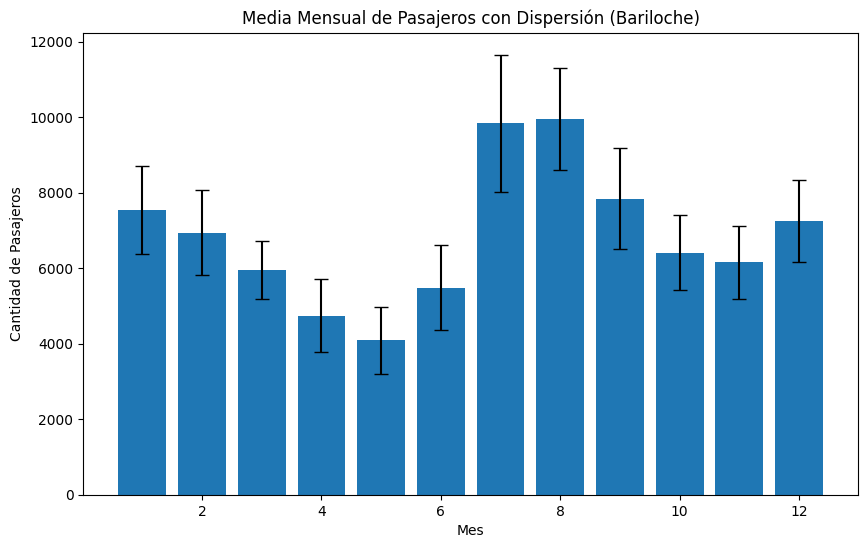

In [ ]:
#  Promedio de pasajeros diarios por mes en Bariloche 

# Sumar todos los pasajeros que llegaron en cada fecha
# Resultado: una fila por día con el total de pasajeros de ese día
pasajeros_por_dia = bariloche.groupby(bariloche['Fecha UTC'].dt.date)['Pasajeros'].sum().reset_index()
pasajeros_por_dia.columns = ['Fecha', 'Total_Pasajeros_Dia']

# Extraer el mes de cada fecha para poder agrupar mensualmente
pasajeros_por_dia['Fecha'] = pd.to_datetime(pasajeros_por_dia['Fecha'])
pasajeros_por_dia['Mes']   = pasajeros_por_dia['Fecha'].dt.month

# Calcular la media y desvío estándar de los totales diarios agrupados por mes
informe_municipal_diario = (
    pasajeros_por_dia
    .groupby('Mes')['Total_Pasajeros_Dia']
    .agg(['mean', 'std'])
    .reset_index()
)
informe_municipal_diario.columns = ['Mes', 'Media_Pasajeros_Diarios', 'Desvio_Estandar_Diario']

print("--- Número promedio de pasajeros diarios por mes ---")
print(informe_municipal_diario)

# Gráfico de barras con barras de error para visualizar la variabilidad mensual
plt.figure(figsize=(10, 6))
plt.bar(
    informe_municipal_diario['Mes'],
    informe_municipal_diario['Media_Pasajeros_Diarios'],
    yerr=informe_municipal_diario['Desvio_Estandar_Diario'],
    capsize=5
)
plt.title('Media Mensual de Pasajeros con Dispersión (Bariloche)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Pasajeros')
plt.show()


In [187]:
mes_max = informe_municipal_diario.loc[
    informe_municipal_diario['Media_Pasajeros_Diarios'].idxmax()
]

In [188]:
print(
    f"Agosto es el pico máximo con el mayor promedio diario de pasajeros: "
    f"{mes_max['Media_Pasajeros_Diarios']:.0f}. "
    f"Al ser el desvío estándar superior a 1331, "
    f"es necesario considerar que pueden recibir algunos días más de "
    f"11.000 pasajeros."
)

Agosto es el pico máximo con el mayor promedio diario de pasajeros: 9958. Al ser el desvío estándar superior a 1331, es necesario considerar que pueden recibir algunos días más de 11.000 pasajeros.


# JULIO / AGOSTO vs MAYO: ¿Cómo varía el comportamiento?


--- Comparación horaria: Mayo vs Invierno ---
    Hora  Promedio_Mayo  Promedio_Invierno  Diferencia  Incremento_%
0      0          205.0              308.0       103.0          50.0
1      1          209.0              259.0        51.0          24.0
2      2          200.0              220.0        20.0          10.0
3      3          138.0              233.0        95.0          69.0
4      4          147.0              162.0        15.0          10.0
5      5          157.0              177.0        20.0          13.0
6      6          158.0              184.0        26.0          16.0
7      7          160.0              168.0         7.0           5.0
8      8           94.0              143.0        50.0          53.0
9      9          148.0              189.0        42.0          28.0
10    10          237.0              280.0        43.0          18.0
11    11          209.0              278.0        69.0          33.0
12    12          197.0              312.0       115.0  

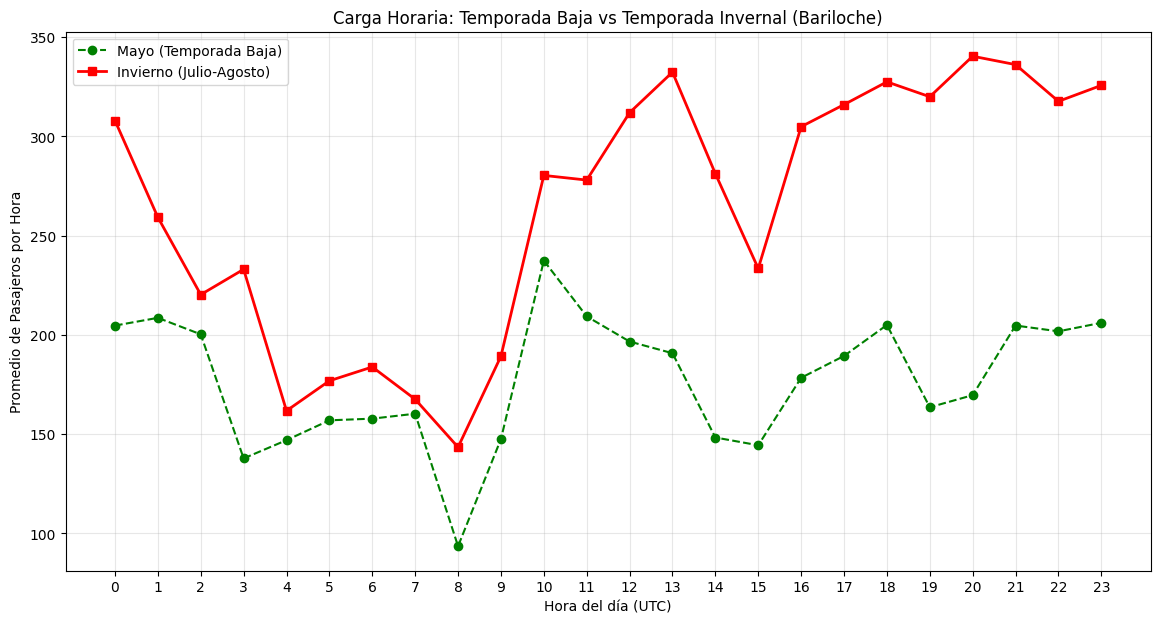

In [ ]:
#  Análisis de carga horaria: temporada alta (agosto) vs. baja (mayo) 
# Extraer la hora
anac['hora'] = pd.to_datetime(anac['Hora UTC'], format='%H:%M').dt.hour

# Filtros
filtro_base = (
    (anac['Tipo de Movimiento'] == 'Aterrizaje') &
    (anac['Aeropuerto'] == 'BAR')
)

df_mayo = anac.loc[
    filtro_base &
    (anac['mes'] == 5)
]

df_invierno = anac.loc[
    filtro_base &
    (anac['mes'].isin([7, 8]))
]

def obtener_promedio_horario(df):
    pax_dia_hora = (
        df.groupby(['Fecha UTC', 'hora'])['Pasajeros']
        .sum()
        .reset_index()
    )

    return (
        pax_dia_hora
        .groupby('hora')['Pasajeros']
        .mean()
        .reset_index()
    )

promedio_mayo = obtener_promedio_horario(df_mayo)
promedio_invierno = obtener_promedio_horario(df_invierno)

# TABLA COMPARATIVA
tabla_comparativa = (
    promedio_mayo
    .merge(
        promedio_invierno,
        on='hora',
        suffixes=('_Mayo', '_Invierno')
    )
)

tabla_comparativa.columns = [
    'Hora',
    'Promedio_Mayo',
    'Promedio_Invierno'
]

tabla_comparativa['Diferencia'] = (
    tabla_comparativa['Promedio_Invierno']
    - tabla_comparativa['Promedio_Mayo']
)

tabla_comparativa['Incremento_%'] = (
    tabla_comparativa['Diferencia']
    / tabla_comparativa['Promedio_Mayo']
    * 100
)

print("\n Comparación horaria: Mayo vs Invierno ")
print(tabla_comparativa.round(0))

# GRÁFICO
plt.figure(figsize=(14, 7))

plt.plot(
    promedio_mayo['hora'],
    promedio_mayo['Pasajeros'],
    label='Mayo (Temporada Baja)',
    color='green',
    marker='o',
    linestyle='--'
)

plt.plot(
    promedio_invierno['hora'],
    promedio_invierno['Pasajeros'],
    label='Invierno (Julio-Agosto)',
    color='red',
    marker='s',
    linewidth=2
)

plt.xticks(range(24))
plt.xlabel('Hora del día (UTC)')
plt.ylabel('Promedio de Pasajeros por Hora')
plt.title('Carga Horaria: Temporada Baja vs Temporada Invernal (Bariloche)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Durante la temporada invernal (julio-agosto), el aeropuerto recibe aproximadamente entre 300 y 340 pasajeros por hora en los momentos de mayor demanda. Las franjas más exigentes se concentran entre las 12:00 y las 23:00 UTC, alcanzando un máximo de 340 pasajeros promedio por hora a las 20:00 UTC. En comparación con mayo, el incremento de pasajeros es especialmente significativo durante la tarde y la noche, llegando incluso a duplicar la demanda en algunas franjas horarias. El caso más destacado se observa a las 20:00 UTC, donde el volumen aumenta un 101% respecto de la temporada baja. Esta situación justifica reforzar la disponibilidad de transporte terrestre, servicios turísticos, personal operativo y capacidad de atención durante gran parte de la jornada.

Las franjas de menor actividad se concentran entre las 04:00 y las 08:00 UTC, registrándose el mínimo absoluto a las 08:00 UTC con un promedio de 143 pasajeros durante la temporada invernal. Sin embargo, incluso en esta hora de menor demanda, el volumen de pasajeros supera en un 53% al observado en mayo, lo que evidencia que la actividad aeroportuaria se mantiene elevada durante todo el período turístico.


# En agosto, ¿Qué día de la semana recibe más pasajeros?

  dia_semana  Pasajeros
0      Lunes     4739.0
1     Martes     4698.0
2  Miércoles     4572.0
3     Jueves     5060.0
4    Viernes     4981.0
5     Sábado     5938.0
6    Domingo     4939.0


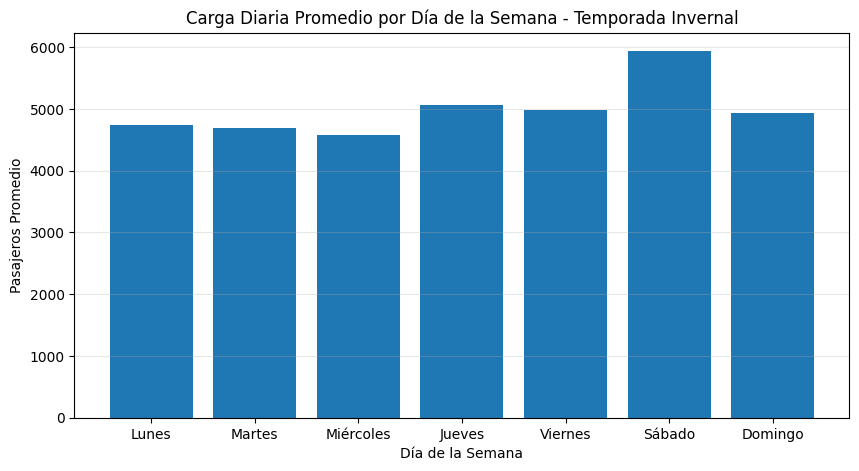

In [ ]:
# Distribución semanal de pasajeros en Bariloche durante Agosto 
# Sumar pasajeros por fecha
pax_diarios_invierno = (
    df_invierno
    .groupby('Fecha UTC')['Pasajeros']
    .sum()
    .reset_index()
)

# Obtener día de la semana
pax_diarios_invierno['dia_semana'] = (
    pax_diarios_invierno['Fecha UTC']
    .dt.day_name()
)

# Orden de días
orden_dias = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Promedio por día de la semana
promedio_invierno_semanal = (
    pax_diarios_invierno
    .groupby('dia_semana')['Pasajeros']
    .mean()
    .reindex(orden_dias)
    .reset_index()
)

# Traducir
promedio_invierno_semanal['dia_semana'] = (
    promedio_invierno_semanal['dia_semana']
    .map(DIAS)
)

print(promedio_invierno_semanal.round(0))

plt.figure(figsize=(10, 5))

plt.bar(
    promedio_invierno_semanal['dia_semana'],
    promedio_invierno_semanal['Pasajeros']
)

plt.title('Carga Diaria Promedio por Día de la Semana - Temporada Invernal')
plt.ylabel('Pasajeros Promedio')
plt.xlabel('Día de la Semana')
plt.grid(axis='y', alpha=0.3)

plt.show()

El análisis de la distribución semanal durante la temporada invernal evidencia una marcada concentración de pasajeros hacia el fin de semana. Los sábados constituyen el día de mayor demanda, con un promedio de 5.938 pasajeros, mientras que los miércoles registran el menor volumen, con 4.572 pasajeros. La diferencia entre ambos extremos alcanza aproximadamente 1.366 pasajeros diarios, lo que representa una variación cercana al 30%. Asimismo, se observa un incremento gradual de la actividad a partir del jueves, alcanzando su máximo durante el sábado. 

# ¿Qué probabilidades pueden estimarse con modelos binomial y Poisson?

- **Binomial:** ¿Cuál es la probabilidad de que, al seleccionar 10 movimientos al azar durante la temporada invernal, al menos 3 transporten más de 174 pasajeros?
- **Poisson:** ¿Cuál es la probabilidad de que, durante un día de la temporada invernal, se registren más de 10 movimientos de muy alta demanda?

In [ ]:
#  Modelo Binomial: movimientos de muy alta demanda durante el invierno 

# Definir el umbral de "muy alta demanda" utilizando el percentil 75. Por que?
# Esto significa que solo el 25% de los movimientos tienen más pasajeros
# que este valor.
umbral_alto = df_invierno['Pasajeros'].quantile(0.75)

print(f"Umbral de muy alta demanda: {umbral_alto:.0f} pasajeros")

# Calcular la probabilidad de que un movimiento supere dicho umbral.
# Esta será la probabilidad de éxito (p) del modelo binomial.
p_alta_demanda = (
    df_invierno['Pasajeros'] > umbral_alto
).mean()

print(f"p = {p_alta_demanda:.3f}")

# Definir los parámetros del experimento.
# Se seleccionan 10 movimientos al azar y se desea conocer la probabilidad
# de que al menos 3 sean de muy alta demanda.
n = 10
k_min = 3

# Calcular P(X ≥ 3) utilizando la distribución binomial.
# Se suman las probabilidades de obtener 3, 4, ..., 10 movimientos
# de muy alta demanda.
prob_binomial_al_menos_3 = sum(
    comb(n, k) * (p_alta_demanda ** k) * ((1 - p_alta_demanda) ** (n - k))
    for k in range(k_min, n + 1)
)

# Mostrar resultados.
print(
    f"Probabilidad de que al menos 3 de 10 movimientos "
    f"sean de muy alta demanda "
)

print(
    f"Porcentaje: {prob_binomial_al_menos_3 * 100:.2f}%"
)

Umbral de muy alta demanda: 174 pasajeros
p = 0.244
Probabilidad de que al menos 3 de 10 movimientos sean de muy alta demanda 
Porcentaje: 45.75%


Se definió como movimiento de muy alta demanda a aquel que transporta más de 174 pasajeros, valor correspondiente al percentil 75 de la distribución de pasajeros durante la temporada invernal. Esto implica que aproximadamente el 24,4% de los movimientos observados supera dicho umbral.

Mediante un modelo binomial se estimó la probabilidad de que, al seleccionar 10 movimientos al azar durante el invierno, al menos 3 correspondan a esta categoría. El resultado obtenido fue del 45,75%, lo que indica que la presencia de movimientos de muy alta demanda es relativamente frecuente durante la temporada turística.


In [ ]:
# Modelo de Poisson: movimientos de muy alta demanda por día

# Definir el umbral de muy alta demanda.
# Se utiliza el percentil 75 de pasajeros de la temporada invernal.
umbral_alto = df_invierno['Pasajeros'].quantile(0.75)

# Identificar los movimientos que superan dicho umbral.
movimientos_altos = df_invierno[
    df_invierno['Pasajeros'] > umbral_alto
]

# Contar cuántos movimientos de muy alta demanda ocurren cada día.
altos_por_dia = (
    movimientos_altos
    .groupby('Fecha UTC')
    .size()
    .reset_index(name='Movimientos_Alta_Demanda')
)

# Calcular λ (lambda), es decir,
# el número promedio diario de movimientos de muy alta demanda.
lambda_poisson = altos_por_dia['Movimientos_Alta_Demanda'].mean()

print(f"Umbral de muy alta demanda: {umbral_alto:.0f} pasajeros")
print(
    f"Promedio diario de movimientos de muy alta demanda (λ): "
    f"{lambda_poisson:.2f}"
)

# Calcular la probabilidad de observar más de 10 movimientos
# de muy alta demanda en un día cualquiera de la temporada invernal.
x = 10

prob_mas_de_10 = 1 - poisson.cdf(x, lambda_poisson)

print(
    f"\nProbabilidad de que un día registre más de {x} "
    f"movimientos de muy alta demanda:"
)
print(f"{prob_mas_de_10:.4f}")
print(f"{prob_mas_de_10 * 100:.2f}%")

Umbral de muy alta demanda: 174 pasajeros
Promedio diario de movimientos de muy alta demanda (λ): 8.27

Probabilidad de que un día registre más de 10 movimientos de muy alta demanda:
0.2122
21.22%


El análisis mediante un modelo de Poisson indica que durante la temporada invernal se producen, en promedio, 8,27 movimientos diarios de muy alta demanda, definidos como aquellos que transportan más de 174 pasajeros. A partir de este promedio, se estimó una probabilidad del 21,22% de que en un día cualquiera se registren más de 10 movimientos de esta categoría.

# Parte predictiva: feriados largos y demanda en Bariloche

Aclaración: en esta sección predictiva se trabaja específicamente con los aterrizajes en el aeropuerto de Bariloche, ya que el objetivo es estimar la llegada de pasajeros al destino turístico. Por este motivo, los valores utilizados en el modelo pueden diferir de otros apartados del trabajo donde se consideran todos los movimientos aeroportuarios, incluyendo aterrizajes y despegues.

In [ ]:
# PARTE PREDICTIVA: FERIADOS LARGOS Y DEMANDA EN BARILOCHE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [194]:
# Nos quedamos solo con Bariloche y con aterrizajes
# Usamos aterrizajes porque representan la llegada de pasajeros al destino turístico.

bariloche_aterrizajes = anac[
    (anac['Aeropuerto'] == 'BAR') &
    (anac['Tipo de Movimiento'] == 'Aterrizaje')
].copy()

# Aseguramos que la fecha esté en formato datetime
bariloche_aterrizajes['Fecha UTC'] = pd.to_datetime(bariloche_aterrizajes['Fecha UTC'])

# Agrupamos por día
# Para cada fecha calculamos:
# - cantidad total de pasajeros
# - cantidad de vuelos/movimientos
# - promedio de pasajeros por vuelo

datos_diarios = (
    bariloche_aterrizajes
    .groupby('Fecha UTC')
    .agg(
        pasajeros_totales=('Pasajeros', 'sum'),
        cantidad_vuelos=('Pasajeros', 'count'),
        pasajeros_promedio_por_vuelo=('Pasajeros', 'mean')
    )
    .reset_index()
)

# Creamos variables de fecha
datos_diarios['anio'] = datos_diarios['Fecha UTC'].dt.year
datos_diarios['mes'] = datos_diarios['Fecha UTC'].dt.month
datos_diarios['dia'] = datos_diarios['Fecha UTC'].dt.day
datos_diarios['dia_semana_num'] = datos_diarios['Fecha UTC'].dt.dayofweek
# Lunes = 0, Martes = 1, ..., Domingo = 6

datos_diarios['es_fin_de_semana'] = datos_diarios['dia_semana_num'].isin([5, 6]).astype(int)

display(datos_diarios.head())

,Fecha UTC,pasajeros_totales,cantidad_vuelos,pasajeros_promedio_por_vuelo,anio,mes,dia,dia_semana_num,es_fin_de_semana
0,2023-01-01,2903.0,23,126.217391,2023,1,1,6,1
1,2023-01-02,3461.0,30,115.366667,2023,1,2,0,0
2,2023-01-03,3600.0,27,133.333333,2023,1,3,1,0
3,2023-01-04,4137.0,32,129.281250,2023,1,4,2,0
4,2023-01-05,3942.0,28,140.785714,2023,1,5,3,0


# Creamos la variable de feriado largo

In [ ]:
# Lista ampliada de períodos considerados feriados, fines de semana largos
# o días no laborables turísticos en Argentina.
# Formato: desde, hasta
# Si el feriado fue de un solo día, inicio y fin son iguales.

feriados_largos = [
    # 2023
    ('2023-01-01', '2023-01-01'),  # Año Nuevo
    ('2023-02-18', '2023-02-21'),  # Carnaval
    ('2023-03-24', '2023-03-26'),  # Día de la Memoria
    ('2023-04-02', '2023-04-02'),  # Malvinas
    ('2023-04-06', '2023-04-09'),  # Jueves Santo + Viernes Santo + Semana Santa
    ('2023-04-29', '2023-05-01'),  # Día del Trabajador
    ('2023-05-25', '2023-05-28'),  # Revolución de Mayo + puente turístico
    ('2023-06-17', '2023-06-20'),  # Güemes + puente turístico + Belgrano
    ('2023-07-09', '2023-07-09'),  # Día de la Independencia
    ('2023-08-19', '2023-08-21'),  # San Martín trasladado
    ('2023-10-13', '2023-10-16'),  # Puente turístico + Diversidad Cultural trasladado
    ('2023-11-18', '2023-11-20'),  # Soberanía Nacional
    ('2023-12-08', '2023-12-10'),  # Inmaculada Concepción
    ('2023-12-23', '2023-12-25'),  # Navidad

    # 2024
    ('2024-01-01', '2024-01-01'),  # Año Nuevo
    ('2024-02-10', '2024-02-13'),  # Carnaval
    ('2024-03-24', '2024-03-24'),  # Día de la Memoria
    ('2024-03-28', '2024-04-02'),  # Semana Santa + puente turístico + Malvinas
    ('2024-05-01', '2024-05-01'),  # Día del Trabajador
    ('2024-05-25', '2024-05-26'),  # Revolución de Mayo
    ('2024-06-15', '2024-06-17'),  # Güemes
    ('2024-06-20', '2024-06-23'),  # Belgrano + puente turístico
    ('2024-07-09', '2024-07-09'),  # Día de la Independencia
    ('2024-08-17', '2024-08-18'),  # San Martín
    ('2024-10-11', '2024-10-13'),  # Puente turístico + Diversidad Cultural
    ('2024-11-16', '2024-11-18'),  # Soberanía Nacional
    ('2024-12-08', '2024-12-08'),  # Inmaculada Concepción
    ('2024-12-25', '2024-12-25'),  # Navidad

    # 2025
    ('2025-01-01', '2025-01-01'),  # Año Nuevo
    ('2025-03-01', '2025-03-04'),  # Carnaval
    ('2025-03-22', '2025-03-24'),  # Día de la Memoria
    ('2025-04-02', '2025-04-02'),  # Malvinas
    ('2025-04-17', '2025-04-20'),  # Jueves Santo + Viernes Santo + Semana Santa
    ('2025-05-01', '2025-05-04'),  # Día del Trabajador + puente turístico
    ('2025-05-25', '2025-05-25'),  # Revolución de Mayo
    ('2025-06-14', '2025-06-16'),  # Güemes trasladado
    ('2025-06-20', '2025-06-22'),  # Belgrano
    ('2025-07-09', '2025-07-09'),  # Día de la Independencia
    ('2025-08-15', '2025-08-17'),  # Puente turístico + San Martín
    ('2025-10-10', '2025-10-12'),  # Diversidad Cultural trasladado
    ('2025-11-21', '2025-11-24'),  # Puente turístico + Soberanía Nacional trasladado
    ('2025-12-06', '2025-12-08'),  # Inmaculada Concepción
    ('2025-12-25', '2025-12-25'),  # Navidad

    # 2026
    # Los dataset llegan a abril y mayo de 2026, los feriados posteriores
    # no afectan el resultado. Pero se dejan cargados igualmente.
    ('2026-01-01', '2026-01-04'),  # Año Nuevo
    ('2026-02-14', '2026-02-17'),  # Carnaval
    ('2026-03-21', '2026-03-24'),  # Puente turístico + Día de la Memoria
    ('2026-04-02', '2026-04-05'),  # Malvinas + Viernes Santo + Semana Santa
    ('2026-05-01', '2026-05-03'),  # Día del Trabajador
    ('2026-05-23', '2026-05-25'),  # Revolución de Mayo
    ('2026-06-13', '2026-06-15'),  # Güemes trasladado
    ('2026-06-20', '2026-06-21'),  # Belgrano
    ('2026-07-09', '2026-07-12'),  # Independencia + puente turístico
    ('2026-08-15', '2026-08-17'),  # San Martín
    ('2026-10-10', '2026-10-12'),  # Diversidad Cultural
    ('2026-11-21', '2026-11-23'),  # Soberanía Nacional
    ('2026-12-05', '2026-12-08'),  # Puente turístico + Inmaculada Concepción
    ('2026-12-25', '2026-12-25'),  # Navidad
]

# Función para identificar si una fecha pertenece a un feriado largo
def marcar_feriado_largo(fecha):
    for inicio, fin in feriados_largos:
        if pd.to_datetime(inicio) <= fecha <= pd.to_datetime(fin):
            return 1
    return 0

# Creamos la variable
datos_diarios['es_feriado_largo'] = datos_diarios['Fecha UTC'].apply(marcar_feriado_largo)
print("Cantidad de días marcados como feriado o fin de semana largo:")
print(datos_diarios['es_feriado_largo'].value_counts())

display(
    datos_diarios[datos_diarios['es_feriado_largo'] == 1]
    [['Fecha UTC', 'pasajeros_totales', 'cantidad_vuelos']]
    .head(20)
)

Cantidad de días marcados como feriado o fin de semana largo:
es_feriado_largo
0    1084
1     129
Name: count, dtype: int64


,Fecha UTC,pasajeros_totales,cantidad_vuelos
0,2023-01-01,2903.0,23
48,2023-02-18,4103.0,29
49,2023-02-19,3858.0,26
50,2023-02-20,3095.0,20
51,2023-02-21,2611.0,32
82,2023-03-24,2781.0,23
83,2023-03-25,2661.0,28
84,2023-03-26,2839.0,29
91,2023-04-02,3244.0,26
95,2023-04-06,3267.0,27


La variable `es_feriado_largo` identifica fechas correspondientes a feriados nacionales, fines de semana largos y días no laborables con fines turísticos dentro del período analizado. Se incluyeron tanto períodos de varios días como feriados de un solo día, debido a que ambos pueden afectar la demanda turística y el movimiento de pasajeros hacia Bariloche.

In [196]:
comparacion_feriados = (
    datos_diarios
    .groupby('es_feriado_largo')
    .agg(
        dias_analizados=('Fecha UTC', 'count'),
        promedio_pasajeros=('pasajeros_totales', 'mean'),
        promedio_vuelos=('cantidad_vuelos', 'mean'),
        promedio_pasajeros_por_vuelo=('pasajeros_promedio_por_vuelo', 'mean')
    )
    .reset_index()
)

comparacion_feriados['tipo_dia'] = comparacion_feriados['es_feriado_largo'].map({
    0: 'Día normal',
    1: 'Feriado largo'
})

display(comparacion_feriados)

,es_feriado_largo,dias_analizados,promedio_pasajeros,promedio_vuelos,promedio_pasajeros_por_vuelo,tipo_dia
0,0,1084,3387.785055,25.26476,135.134370,Día normal
1,1,129,3369.581395,25.24031,134.731874,Feriado largo


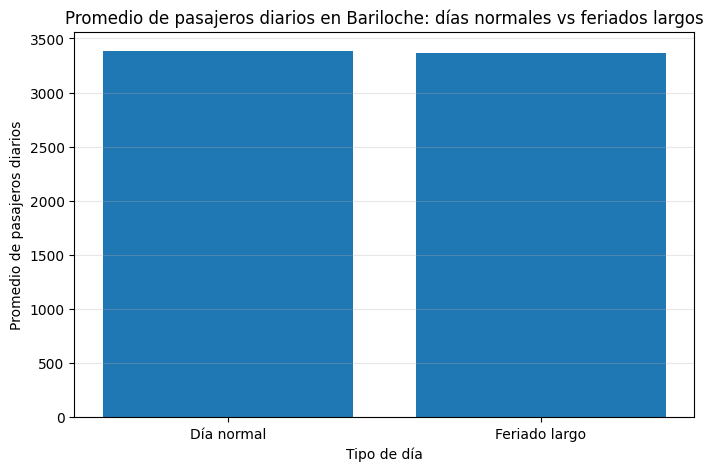

In [197]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparacion_feriados['tipo_dia'],
    comparacion_feriados['promedio_pasajeros']
)

plt.title('Promedio de pasajeros diarios en Bariloche: días normales vs feriados largos')
plt.xlabel('Tipo de día')
plt.ylabel('Promedio de pasajeros diarios')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [198]:
# Variables predictoras
X = datos_diarios[
    [
        'mes',
        'dia_semana_num',
        'es_fin_de_semana',
        'es_feriado_largo',
        'cantidad_vuelos'
    ]
]

# Variable objetivo
y = datos_diarios['pasajeros_totales']

# Dividimos datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Creamos el modelo
modelo = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Entrenamos el modelo
modelo.fit(X_train, y_train)

# Hacemos predicciones
y_pred = modelo.predict(X_test)

# Evaluamos el modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluación del modelo predictivo")
print("--------------------------------")
print(f"Error absoluto medio MAE: {mae:.2f} pasajeros")
print(f"R2 del modelo: {r2:.2f}")

Evaluación del modelo predictivo
--------------------------------
Error absoluto medio MAE: 326.41 pasajeros
R2 del modelo: 0.86


,variable,importancia
4,cantidad_vuelos,0.799479
0,mes,0.155860
1,dia_semana_num,0.033064
3,es_feriado_largo,0.006601
2,es_fin_de_semana,0.004996


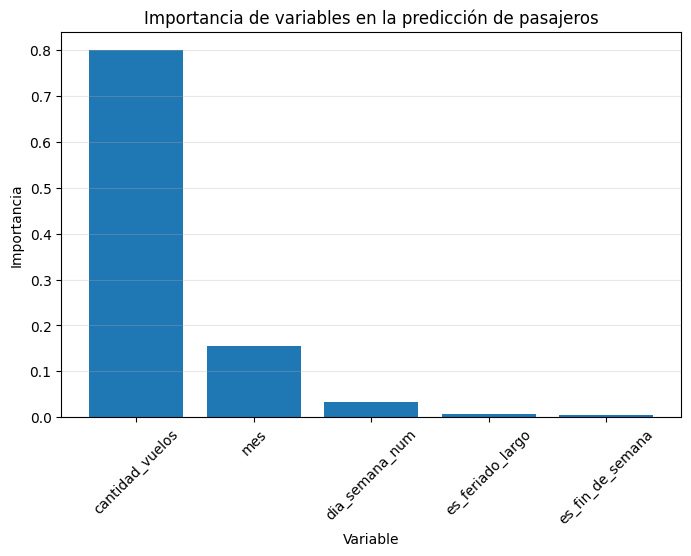

In [199]:
importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': modelo.feature_importances_
}).sort_values(by='importancia', ascending=False)

display(importancias)

plt.figure(figsize=(8, 5))

plt.bar(
    importancias['variable'],
    importancias['importancia']
)

plt.title('Importancia de variables en la predicción de pasajeros')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

# Ejemplos de predicciones para días específicos

In [ ]:
# Simulación de un escenario futuro
# Ejemplo: julio, sábado, feriado largo, con 35 vuelos estimados

nuevo_escenario = pd.DataFrame({
    'mes': [7],
    'dia_semana_num': [5],       # sábado
    'es_fin_de_semana': [1],
    'es_feriado_largo': [1],
    'cantidad_vuelos': [35]
})

prediccion_pasajeros = modelo.predict(nuevo_escenario)

print("Predicción para escenario de feriado largo")
print(f"Pasajeros diarios estimados: {prediccion_pasajeros[0]:.0f}")

Predicción para escenario de feriado largo
-----------------------------------------
Pasajeros diarios estimados: 4947


In [ ]:
escenario_normal = pd.DataFrame({
    'mes': [7],
    'dia_semana_num': [2],       # miércoles
    'es_fin_de_semana': [0],
    'es_feriado_largo': [0],
    'cantidad_vuelos': [25]
})

prediccion_normal = modelo.predict(escenario_normal)

print("Comparación predictiva")
print(f"Día normal estimado: {prediccion_normal[0]:.0f} pasajeros")
print(f"Feriado largo estimado: {prediccion_pasajeros[0]:.0f} pasajeros")

diferencia = prediccion_pasajeros[0] - prediccion_normal[0]
porcentaje = diferencia / prediccion_normal[0] * 100

print(f"Diferencia estimada: {diferencia:.0f} pasajeros")
print(f"Incremento estimado: {porcentaje:.2f}%")

Comparación predictiva
----------------------
Día normal estimado: 3624 pasajeros
Feriado largo estimado: 4947 pasajeros
Diferencia estimada: 1323 pasajeros
Incremento estimado: 36.51%


Para la parte predictiva se construyeron dos modelos que estiman la cantidad diaria de pasajeros que arriban al aeropuerto de Bariloche. Para ello se utilizaron variables temporales como el mes, el día de la semana, si corresponde a fin de semana y si pertenece a un feriado largo. También se incorporó la cantidad de vuelos diarios como indicador de actividad aeroportuaria.

La variable es_feriado_largo permite identificar períodos de mayor movimiento turístico. A partir de esta variable, el modelo puede comparar días normales con fines de semana largos y estimar el posible incremento de pasajeros.

Esta predicción resulta útil para la empresa u organismo solicitante porque permite anticipar escenarios de alta demanda, reforzar personal, coordinar transporte público y traslados turísticos, y mejorar la planificación operativa del aeropuerto durante fechas críticas.

# Modelo Alternativo

En el modelo predictivo, la variable con mayor importancia fue la cantidad de vuelos diarios, lo cual indica que el volumen de pasajeros depende principalmente de la cantidad de vuelos programados. La variable feriado largo tuvo una incidencia menor, ya que en los datos analizados no se observa una diferencia muy marcada entre el promedio de pasajeros de días normales y feriados largos.

In [ ]:
# Modelo alternativo sin cantidad_vuelos
# Este modelo sirve para ver mejor el efecto de las variables de calendario,
# como mes, día de semana, fin de semana y feriado largo.

X_calendario = datos_diarios[
    [
        'mes',
        'dia_semana_num',
        'es_fin_de_semana',
        'es_feriado_largo'
    ]
]

y = datos_diarios['pasajeros_totales']

X_train, X_test, y_train, y_test = train_test_split(
    X_calendario,
    y,
    test_size=0.2,
    random_state=42
)

modelo_calendario = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_calendario.fit(X_train, y_train)

y_pred = modelo_calendario.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluación del modelo predictivo sin cantidad de vuelos")
print(f"Error absoluto medio MAE: {mae:.2f} pasajeros")
print(f"R2 del modelo: {r2:.2f}")

Evaluación del modelo predictivo sin cantidad de vuelos
------------------------------------------------------
Error absoluto medio MAE: 445.71 pasajeros
R2 del modelo: 0.72


,variable,importancia
0,mes,0.861827
1,dia_semana_num,0.097446
2,es_fin_de_semana,0.020968
3,es_feriado_largo,0.019759


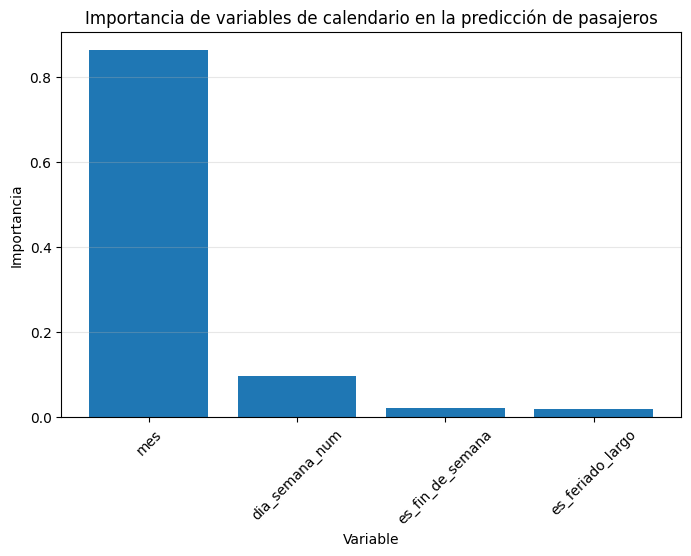

In [203]:
importancias_calendario = pd.DataFrame({
    'variable': X_calendario.columns,
    'importancia': modelo_calendario.feature_importances_
}).sort_values(by='importancia', ascending=False)

display(importancias_calendario)

plt.figure(figsize=(8, 5))

plt.bar(
    importancias_calendario['variable'],
    importancias_calendario['importancia']
)

plt.title('Importancia de variables de calendario en la predicción de pasajeros')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

El primer modelo incluyó la cantidad de vuelos diarios y mostró que esta variable es la principal explicación del volumen de pasajeros. Luego se realizó un segundo modelo sin la variable cantidad de vuelos, con el objetivo de observar mejor el efecto de las variables de calendario, como el mes, el día de la semana, el fin de semana y los feriados largos.

El modelo predictivo sin la variable cantidad de vuelos obtuvo un R2 de 0.73, lo que indica una capacidad aceptable para estimar la cantidad diaria de pasajeros a partir de variables de calendario.

La variable más importante fue el mes, lo cual resulta coherente con el comportamiento turístico de Bariloche, ya que la demanda aérea varía fuertemente según la temporada del año. En cambio, la variable feriado largo tuvo una importancia menor, lo que sugiere que los fines de semana largos influyen en la demanda, pero no tanto como la estacionalidad mensual.

# Comparación entre valores reales y valores predichos

In [204]:

comparacion_predicciones = pd.DataFrame({
    'pasajeros_reales': y_test.values,
    'pasajeros_predichos': y_pred
})

comparacion_predicciones['diferencia'] = (
    comparacion_predicciones['pasajeros_reales'] - comparacion_predicciones['pasajeros_predichos']
)

display(comparacion_predicciones.head(10))

,pasajeros_reales,pasajeros_predichos,diferencia
0,3545.0,3860.265585,-315.265585
1,3260.0,3109.854234,150.145766
2,3476.0,3306.812240,169.187760
3,2443.0,2523.460250,-80.460250
4,1897.0,2279.359064,-382.359064
5,5275.0,4694.095670,580.904330
6,3649.0,4174.622537,-525.622537
7,4417.0,4755.860928,-338.860928
8,2223.0,1813.173900,409.826100
9,1655.0,2362.029600,-707.029600


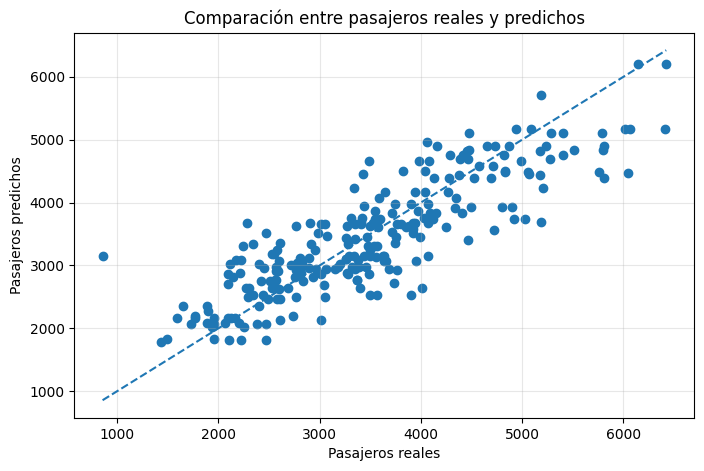

In [205]:
plt.figure(figsize=(8, 5))

plt.scatter(
    comparacion_predicciones['pasajeros_reales'],
    comparacion_predicciones['pasajeros_predichos']
)

# Línea de referencia: predicción perfecta
min_val = min(
    comparacion_predicciones['pasajeros_reales'].min(),
    comparacion_predicciones['pasajeros_predichos'].min()
)

max_val = max(
    comparacion_predicciones['pasajeros_reales'].max(),
    comparacion_predicciones['pasajeros_predichos'].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.title('Comparación entre pasajeros reales y predichos')
plt.xlabel('Pasajeros reales')
plt.ylabel('Pasajeros predichos')
plt.grid(alpha=0.3)

plt.show()

La línea diagonal representa una predicción perfecta. Los puntos cercanos a esa línea indican predicciones más precisas, mientras que los puntos alejados muestran una mayor diferencia entre el valor real y el valor estimado.

In [206]:
# Creamos una columna para clasificar días de alta demanda

umbral_alta_demanda = datos_diarios['pasajeros_totales'].quantile(0.75)

datos_diarios['alta_demanda'] = np.where(
    datos_diarios['pasajeros_totales'] >= umbral_alta_demanda,
    1,
    0
)

print(f"Umbral de alta demanda: {umbral_alta_demanda:.0f} pasajeros diarios")

display(datos_diarios[['Fecha UTC', 'pasajeros_totales', 'alta_demanda']].head())

Umbral de alta demanda: 4011 pasajeros diarios


,Fecha UTC,pasajeros_totales,alta_demanda
0,2023-01-01,2903.0,0
1,2023-01-02,3461.0,0
2,2023-01-03,3600.0,0
3,2023-01-04,4137.0,1
4,2023-01-05,3942.0,0


In [207]:
alta_demanda_feriados = (
    datos_diarios
    .groupby('es_feriado_largo')
    .agg(
        cantidad_dias=('Fecha UTC', 'count'),
        dias_alta_demanda=('alta_demanda', 'sum'),
        porcentaje_alta_demanda=('alta_demanda', 'mean')
    )
    .reset_index()
)

alta_demanda_feriados['porcentaje_alta_demanda'] = (
    alta_demanda_feriados['porcentaje_alta_demanda'] * 100
)

alta_demanda_feriados['tipo_dia'] = alta_demanda_feriados['es_feriado_largo'].map({
    0: 'Día normal',
    1: 'Feriado largo'
})

display(alta_demanda_feriados)

,es_feriado_largo,cantidad_dias,dias_alta_demanda,porcentaje_alta_demanda,tipo_dia
0,0,1084,278,25.645756,Día normal
1,1,129,26,20.155039,Feriado largo


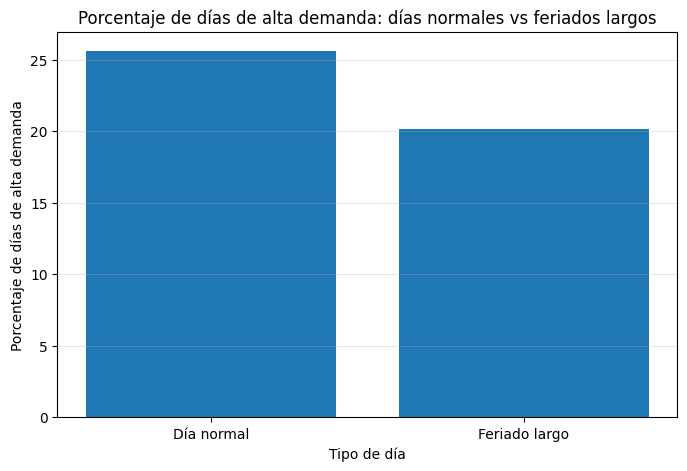

In [208]:
plt.figure(figsize=(8, 5))

plt.bar(
    alta_demanda_feriados['tipo_dia'],
    alta_demanda_feriados['porcentaje_alta_demanda']
)

plt.title('Porcentaje de días de alta demanda: días normales vs feriados largos')
plt.xlabel('Tipo de día')
plt.ylabel('Porcentaje de días de alta demanda')
plt.grid(axis='y', alpha=0.3)

plt.show()

Se definió como día de alta demanda a aquellos días que se encuentran dentro del 25% con mayor cantidad de pasajeros. Esta clasificación permite transformar el análisis predictivo en una herramienta de alerta para la empresa. Si un día futuro presenta características similares a los días de alta demanda, la empresa podría anticipar refuerzos en personal, transporte, atención al pasajero y coordinación operativa.

# Ejemplos de escenarios para la empresa

In [209]:
# Simulación de escenarios futuros con el modelo de calendario

escenarios = pd.DataFrame({
    'mes': [1, 7, 7, 10, 12],
    'dia_semana_num': [2, 5, 6, 5, 4],
    'es_fin_de_semana': [0, 1, 1, 1, 0],
    'es_feriado_largo': [0, 0, 1, 1, 1]
})

escenarios['descripcion'] = [
    'Día normal de enero',
    'Sábado de julio',
    'Domingo de julio en feriado largo',
    'Sábado de octubre en feriado largo',
    'Viernes de diciembre en feriado largo'
]

# Reordenamos columnas para predecir
X_escenarios = escenarios[
    [
        'mes',
        'dia_semana_num',
        'es_fin_de_semana',
        'es_feriado_largo'
    ]
]

escenarios['pasajeros_estimados'] = modelo_calendario.predict(X_escenarios)

display(escenarios[['descripcion', 'pasajeros_estimados']])

,descripcion,pasajeros_estimados
0,Día normal de enero,3448.561820
1,Sábado de julio,6209.400705
2,Domingo de julio en feriado largo,4469.292976
3,Sábado de octubre en feriado largo,3920.174722
4,Viernes de diciembre en feriado largo,3460.104338


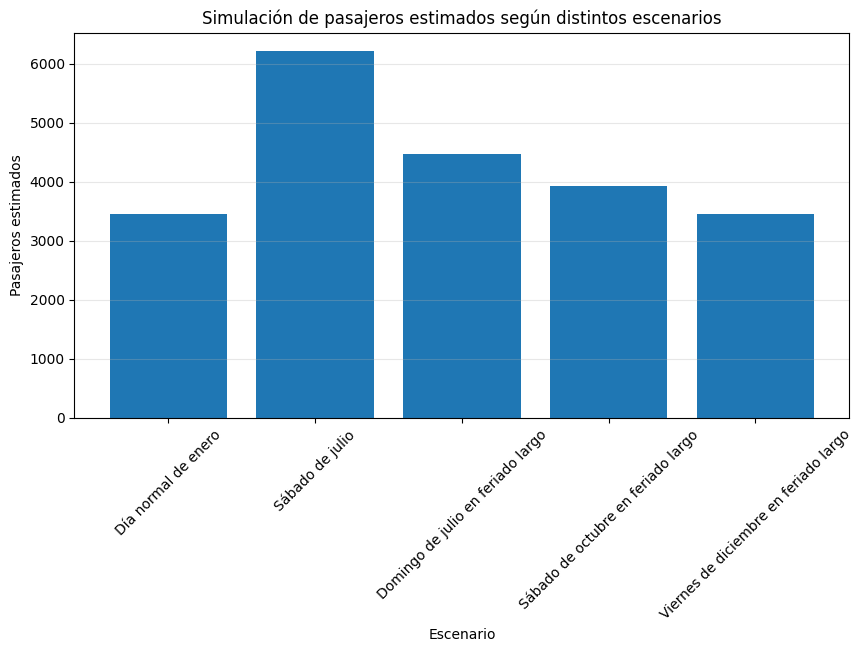

In [210]:
plt.figure(figsize=(10, 5))

plt.bar(
    escenarios['descripcion'],
    escenarios['pasajeros_estimados']
)

plt.title('Simulación de pasajeros estimados según distintos escenarios')
plt.xlabel('Escenario')
plt.ylabel('Pasajeros estimados')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

A partir de los modelos predictivos desarrollados, se observa que la demanda aérea hacia Bariloche está fuertemente influenciada por la estacionalidad mensual. Esto significa que la empresa debe prestar especial atención a los meses de mayor movimiento turístico, principalmente aquellos vinculados con temporada alta.

Si bien los feriados largos no aparecen como la variable más influyente del modelo, siguen siendo relevantes para la planificación operativa, ya que pueden coincidir con períodos de alta demanda. Por este motivo, se recomienda utilizar el modelo como una herramienta de alerta temprana para anticipar días críticos.

La empresa podría aplicar este tipo de predicción para reforzar personal, mejorar la atención al pasajero, coordinar mejor los servicios de transporte y anticipar posibles saturaciones durante fechas turísticas clave.

# Limitaciones del modelo predictivo

Si bien los modelos desarrollados permiten estimar la demanda diaria de pasajeros en Bariloche, deben interpretarse como una herramienta de apoyo para la toma de decisiones y no como una predicción exacta.

Una limitación importante es que el modelo utiliza principalmente variables de calendario, como mes, día de la semana, fin de semana y feriado largo. Sin embargo, la demanda aérea también puede verse afectada por otros factores que no están incluidos en el dataset, como condiciones climáticas, precios de pasajes, cancelaciones, promociones turísticas, eventos especiales, capacidad de alojamiento y decisiones operativas de las aerolíneas.

Además, en el primer modelo la variable cantidad de vuelos tiene una influencia muy alta, lo cual es lógico porque a mayor cantidad de vuelos suele haber mayor cantidad de pasajeros. Por eso también se construyó un modelo alternativo sin esa variable, para observar mejor el efecto de la estacionalidad y de los feriados largos.

# Recomendaciones


A partir de los resultados obtenidos en los modelos predictivos, se recomienda que la empresa utilice la estacionalidad mensual como principal criterio de planificación, ya que el mes fue la variable con mayor importancia para estimar la cantidad diaria de pasajeros que arriban a Bariloche.

Esto indica que la empresa debería anticipar sus recursos principalmente en los meses de mayor demanda turística, especialmente durante la temporada alta. En estos períodos se recomienda reforzar el personal operativo, mejorar la coordinación con los servicios de transporte y prever una mayor demanda en la atención al pasajero.

Si bien los feriados largos no fueron la variable más influyente del modelo, deben ser considerados como fechas de posible refuerzo operativo, ya que pueden coincidir con períodos de alta demanda. Por este motivo, se recomienda incluirlos dentro de una planificación más amplia basada en la temporada del año.

Además, la empresa podría utilizar el modelo predictivo como una herramienta de alerta temprana. Si el modelo estima una cantidad elevada de pasajeros para una fecha determinada, se podrían tomar medidas preventivas, como aumentar la disponibilidad de transporte, reforzar turnos de trabajo, mejorar la comunicación con los pasajeros y coordinar con aerolíneas y prestadores turísticos.

En conclusión, la principal recomendación es no planificar únicamente en función de los feriados largos, sino combinar esa información con la estacionalidad mensual y los datos históricos de pasajeros para anticipar momentos críticos y mejorar la experiencia de quienes llegan a Bariloche.

# Conclusión

El análisis de los datos de aterrizajes y despegues de la ANAC correspondientes al período 2023–2025 demuestra que el aeropuerto de Bariloche presenta una fuerte estacionalidad asociada al turismo. Si bien el promedio diario de pasajeros ronda los **6.800 pasajeros**, la demanda varía significativamente a lo largo del año, alcanzando sus **máximos durante la temporada invernal**.

Los meses de **julio y agosto** concentran la mayor actividad, siendo agosto el mes con el promedio diario más elevado, cercano a los **10.000** pasajeros por día. Esta situación implica un incremento importante en la utilización de la infraestructura aeroportuaria y en la demanda de servicios asociados al transporte turístico.

Las medidas estadísticas muestran una dispersión considerable de los datos (desvío estándar cercano a 2.000 pasajeros diarios), lo que indica que la afluencia de viajeros puede fluctuar notablemente entre distintos días y temporadas. Además, el análisis horario evidencia una mayor concentración de pasajeros durante el invierno, especialmente en las franjas centrales del día.

La distribución semanal revela que los **sábados** son los días de mayor movimiento de pasajeros durante agosto, información relevante para la planificación operativa de aerolíneas, aeropuerto, transporte terrestre y servicios turísticos.

Finalmente, los modelos probabilísticos aplicados permitieron cuantificar distintos escenarios de alta demanda durante la temporada invernal. Por un lado, el modelo binomial estimó una probabilidad cercana al 46% de que, en un conjunto de diez movimientos seleccionados al azar, al menos tres correspondan a operaciones de muy alta demanda. Por otro lado, el modelo de Poisson indicó una probabilidad aproximada del 21% de que un día cualquiera de la temporada invernal registre más de diez movimientos de muy alta demanda. Estos resultados evidencian que los períodos de elevada concentración de pasajeros constituyen una situación relativamente frecuente en el aeropuerto de Bariloche durante los meses de invierno.

En conjunto, los resultados confirman que Bariloche es uno de los principales polos receptores de pasajeros del país y que la planificación de recursos, infraestructura y servicios debe contemplar especialmente los períodos de temporada alta, donde la demanda puede superar ampliamente los niveles promedio anuales.

# Bibliografía

- Administración Nacional de Aviación Civil (ANAC). Datos de aterrizajes y despegues publicados en datos.gob.ar.
- Datos Argentina. Dataset de transporte aéreo y movimientos aeroportuarios: https://www.datos.gob.ar/
- Tableros Yvera. Dataset de conectividad aérea: https://tableros.yvera.tur.ar/conectividad/
- Failbondi. Información de vuelos y demoras: https://failbondi.fail/acerca
- Material de clase de Matemática IV e Introducción a Ciencia de Datos.
- Ampliar bibliografia de ds y especificamente transporte


In [ ]:
El repositorio con los dataset se encuentra en: https://github.com/mletelle/MateIV_Transporte_Publico/ 